In [20]:
import sys

# jupyter kernels use the notebook's own directory as the cwd, not wherever
# jupyter lab was launched from, so the repo root needs to be added manually
# for `from src...` imports to resolve.
sys.path.append("../")

# Inspect an existing model

In [21]:
from src.modeling.utils import load_mlflow_model

pipeline, version = load_mlflow_model(target="fantasy_points_ppr", model_type="random_forest", tracking_dir="../mlruns")
#print(f"pipeline: {pipeline}")
print(f"Loaded version {version}")

model = pipeline['model']
print(f"model: {model}")

Loaded version 9
model: RandomForestRegressor(oob_score=True)


/Users/vivek.sivakumar/Code/personal/ff-model/notebooks/../src/modeling/utils.py:85: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  model_version = client.get_latest_versions(registered_name, stages=["None"])[0].version


# View the training data

In [22]:
from src.modeling.tabular_models import TabularModel

tab_model = TabularModel(data_dir="../data", tracking_dir="../mlruns", target="fantasy_points_ppr", excluded_features=["fantasy_points*"])
datasets = tab_model.split_data()

train_df = datasets["X_train"]
train_df.head(10)

2026-08-07 14:58:28,686 - src.modeling.tabular_models - INFO - load_data - Loaded data: 11152 rows


,completions,attempts,passing_yards,passing_tds,passing_interceptions,passing_first_downs,passing_2pt_conversions,passing_air_yards,passing_yards_after_catch,sacks_suffered,...,team_shift_receiving_2pt_conversions,team_shift_receiving_fumbles,team_shift_receiving_fumbles_lost,team_shift_receiving_air_yards,team_shift_receiving_yards_after_catch,team_shift_receiving_10,team_shift_receiving_16,team_shift_receiving_20,team_shift_receiving_40,team_shift_receiving_epa
0,343.0,569.0,4436.0,36.0,15.0,208.0,0.0,394.0,4290.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-4.0,-3.0,135.0,114.0,-84.0,-48.0,-27.0,-6.0,-100.50
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
5,305.0,537.0,3985.0,19.0,21.0,184.0,0.0,319.0,3982.0,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,3.0,-674.0,-161.0,21.0,12.0,5.0,-1.0,-60.59
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


# Feature Importance

In [23]:
import pandas as pd

def get_feat_importance(model, train_df):
    return pd.DataFrame({'feature':train_df.columns, 'importance':model.feature_importances_}).sort_values('importance', ascending=False)

def plot_feature_importance(fi, num_f=30):
    return fi[:num_f].plot('feature', 'importance', 'barh', figsize=(12,7), legend=False)

<Axes: ylabel='feature'>

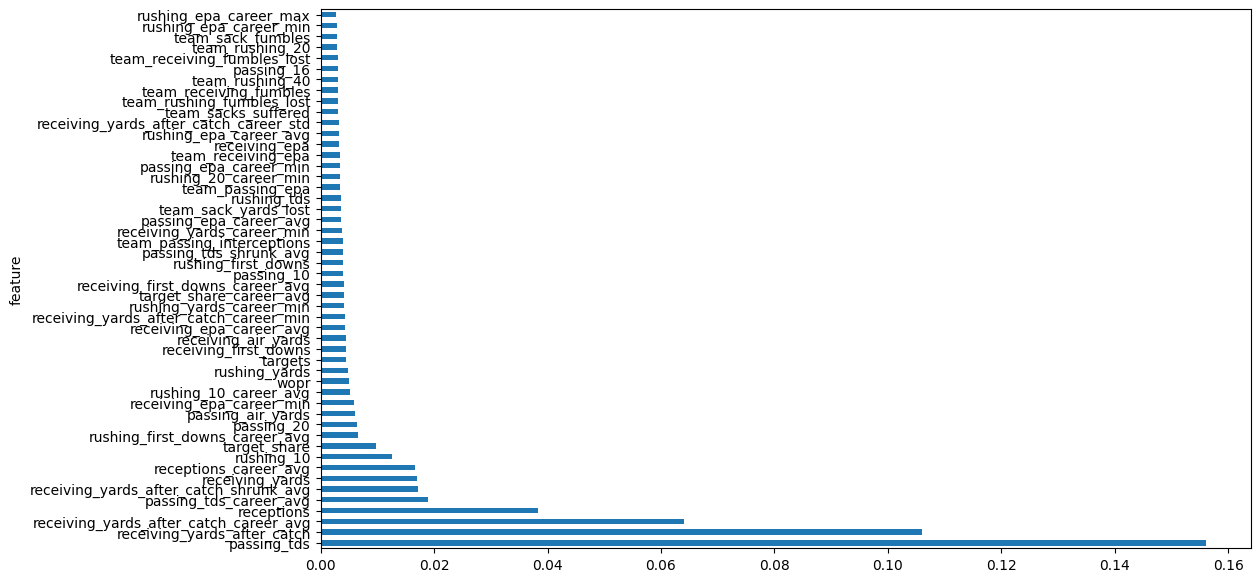

In [24]:
feature_imp = get_feat_importance(model=model, train_df=train_df)

plot_feature_importance(fi=feature_imp, num_f=50)

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model, train_df, train_df.columns[-5:-2])


## What other columns could be features?

In [ ]:
player = nfl.load_player_stats([2025]).to_pandas()
print(f"player stats columns: {player.columns.tolist()}")

In [ ]:
team = nfl.load_team_stats([2025]).to_pandas()
print(f"team stats columns: {team.columns.tolist()}")

In [16]:
snaps = nfl.load_snap_counts([2025]).to_pandas()
print(f"snap counts columns: {snaps.columns.tolist()}")

snap counts columns: ['game_id', 'pfr_game_id', 'season', 'game_type', 'week', 'player', 'pfr_player_id', 'position', 'team', 'opponent', 'offense_snaps', 'offense_pct', 'defense_snaps', 'defense_pct', 'st_snaps', 'st_pct']


In [18]:
draft = nfl.load_draft_picks([2020]).to_pandas()
print(f"draft picks columns: {draft.columns.tolist()}")

draft picks columns: ['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id', 'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category', 'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started', 'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts', 'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards', 'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles', 'def_ints', 'def_sacks']


In [19]:
ff_opportunity = nfl.load_ff_opportunity([2025]).to_pandas()
print(f"team ff_opportunity columns: {ff_opportunity.columns.tolist()}")

team ff_opportunity columns: ['season', 'posteam', 'week', 'game_id', 'player_id', 'full_name', 'position', 'pass_attempt', 'rec_attempt', 'rush_attempt', 'pass_air_yards', 'rec_air_yards', 'pass_completions', 'receptions', 'pass_completions_exp', 'receptions_exp', 'pass_yards_gained', 'rec_yards_gained', 'rush_yards_gained', 'pass_yards_gained_exp', 'rec_yards_gained_exp', 'rush_yards_gained_exp', 'pass_touchdown', 'rec_touchdown', 'rush_touchdown', 'pass_touchdown_exp', 'rec_touchdown_exp', 'rush_touchdown_exp', 'pass_two_point_conv', 'rec_two_point_conv', 'rush_two_point_conv', 'pass_two_point_conv_exp', 'rec_two_point_conv_exp', 'rush_two_point_conv_exp', 'pass_first_down', 'rec_first_down', 'rush_first_down', 'pass_first_down_exp', 'rec_first_down_exp', 'rush_first_down_exp', 'pass_interception', 'rec_interception', 'pass_interception_exp', 'rec_interception_exp', 'rec_fumble_lost', 'rush_fumble_lost', 'pass_fantasy_points_exp', 'rec_fantasy_points_exp', 'rush_fantasy_points_exp',

## Rankings!

In [ ]:
from src.rankings import Rankings

ranker = Rankings(year=2025, target_col="ppr_fantasy_points_per_game")
rankings = ranker.build_rankings()

ranker.plot_rankings(rankings)

# 

# 

# 